# Tree-Based Model Training & Tuning

This notebook trains tree-based classifiers on the linearized session windows data using all available numerical features.
We tune a Random Forest with a single static validation split (PredefinedSplit), then compare it with a few other tree-based models.

The final tuned model is evaluated on the test split and, if available, on the real database export dataset.

In [1]:
import sys
from pathlib import Path

# Add project root directory to path for imports
sys.path.append(str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, train_test_split
from sklearn.metrics import accuracy_score, f1_score
from scripts.data_loader import load_and_preprocess_data
from scripts.evaluation_metrics import evaluate_model

## Load and Preprocess Data

We load the data and extract scaled features, targets, and the fitted scaler using our shared preprocessing script.

In [2]:
X_train, X_test, y_train, y_test, scaler = load_and_preprocess_data()
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (9081, 16)
Test set shape: (2271, 16)


## Data Distribution

A quick check of the target distribution before training.

,Train,Test
rating,,
1.0,167,42
2.0,1352,338
3.0,5258,1315
4.0,1327,332
5.0,977,244


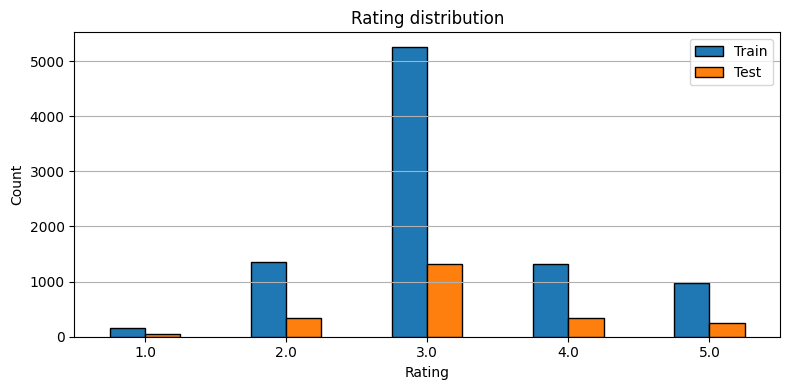

In [3]:
class_counts = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Test": y_test.value_counts().sort_index(),
}).fillna(0).astype(int)

display(class_counts)

class_counts.plot(kind="bar", figsize=(8, 4), edgecolor="black")
plt.title("Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning via Randomized Search

We use a static validation split (holdout set) rather than K-Fold cross-validation to save compute time and keep the setup aligned with the KNN and Neural Network notebooks.

In [4]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

# Split training data to create a single static validation set (holdout)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Create a PredefinedSplit where training is -1 and validation is 0
split_index = [-1] * len(X_tr) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

# Combine train and validation sets back together for fit()
X_tune = pd.concat([X_tr, X_val])
y_tune = pd.concat([y_tr, y_val])

base_model = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=15,
    cv=pds,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_tune, y_tune)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Validation Accuracy: {random_search.best_score_:.4f}")

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best Validation Accuracy: 0.6890


## Evaluate Best Model

We evaluate the optimized Random Forest on the test split of the training dataset.


--- Train Metrics ---
Accuracy:  0.9993
Precision (weighted): 0.9993
Recall (weighted):    0.9993
F1 Score (weighted):  0.9993

--- Test/Validation Metrics ---
Accuracy:  0.6737
Precision (weighted): 0.6563
Recall (weighted):    0.6737
F1 Score (weighted):  0.6499

--- Feature Importances (Top 20) ---
meanTemp              0.111119
light_max             0.100141
maxTemp               0.082658
minTemp               0.074641
light_mean            0.073124
currentTemperature    0.065678
co2_min               0.064601
co2_mean              0.055344
co2_latest            0.054894
co2_max               0.053445
light_latest          0.051230
humidity_mean         0.050527
light_min             0.044293
humidity_min          0.043476
humidity_latest       0.037631
humidity_max          0.037197
dtype: float64


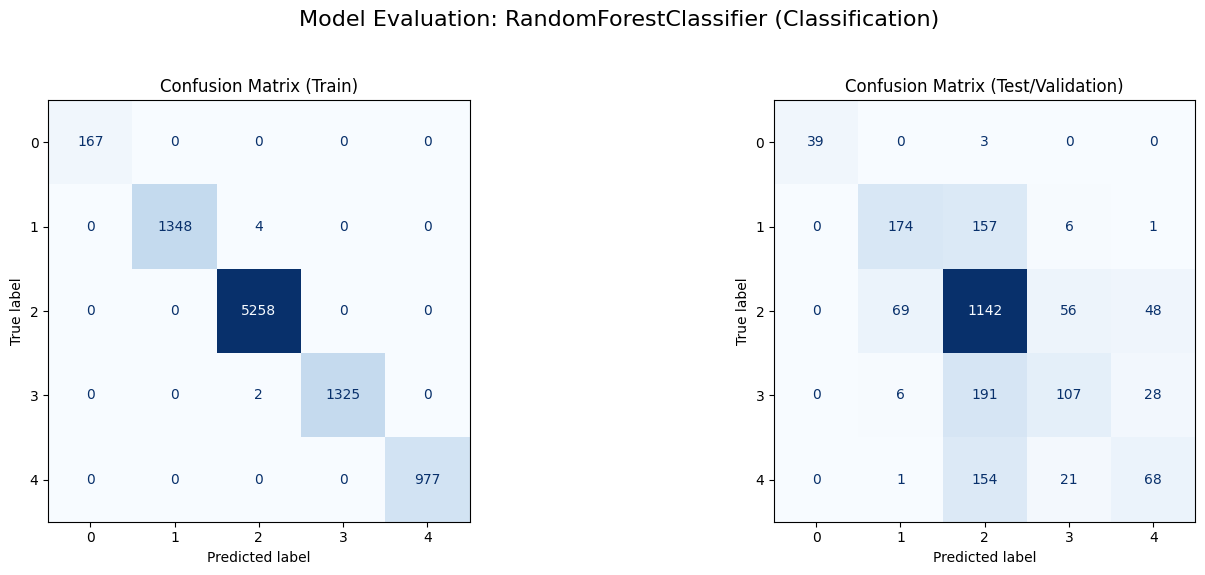

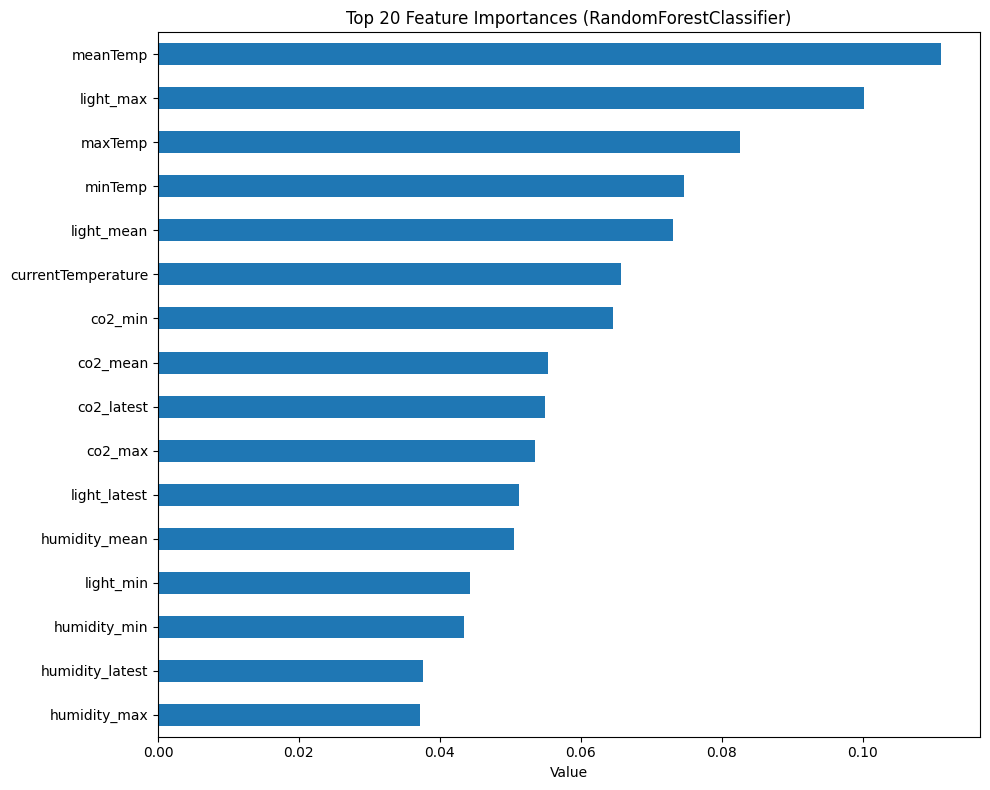

In [5]:
best_model = random_search.best_estimator_
figures = evaluate_model(best_model, X_train, X_test, y_train, y_test, is_classification=True)

## Evaluate on Real Production Data

We load the real session data exported from the database, scale it using the same scaler fitted on our training data, and evaluate our tuned model on it.

In [6]:
# Path to real data generated from the production database
real_data_path = Path("../../data/real/linearized_sessions_with_target.csv")

if real_data_path.exists() and real_data_path.stat().st_size > 0:
    try:
        real_df = pd.read_csv(real_data_path).dropna(subset=["rating"])
        if not real_df.empty:
            # Select features (must match the same feature columns used in training)
            X_real = real_df[X_train.columns]
            y_real = real_df["rating"]

            # Scale real features using the same scaler fitted on training data
            X_real_scaled = pd.DataFrame(
                scaler.transform(X_real),
                columns=X_real.columns,
                index=X_real.index,
            )

            print(f"Loaded {len(real_df)} real sessions for evaluation.")
            figs_real = evaluate_model(best_model, X_train, X_real_scaled, y_train, y_real, is_classification=True)
        else:
            print("Real data CSV is empty.")
    except pd.errors.EmptyDataError:
        print("Real data CSV is empty.")
    except Exception as e:
        print(f"Could not load or evaluate real data: {e}")
else:
    print(f"No real data available for testing at: {real_data_path}")

Real data CSV is empty.


## Accuracy Comparison

This compares the different tree-based models tested in this notebook on the same train/test split.

,Train Accuracy,Test Accuracy,Test Macro F1
Model,,,
Random Forest,0.9993,0.6737,0.6171
Gradient Boosting,0.6999,0.6649,0.5497
Decision Tree,0.6620,0.6574,0.5072


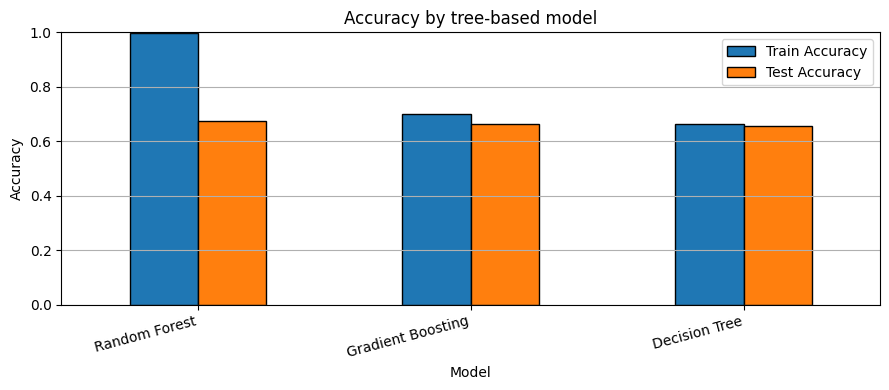

In [7]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": best_model,
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42),
}

results = []
for model_name, model in models.items():
    if model_name != "Random Forest":
        model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Test Macro F1": f1_score(y_test, test_pred, average="macro", zero_division=0),
    })

accuracy_comparison = pd.DataFrame(results).set_index("Model").sort_values("Test Accuracy", ascending=False).round(4)
display(accuracy_comparison)

accuracy_comparison[["Train Accuracy", "Test Accuracy"]].plot(kind="bar", figsize=(9, 4), edgecolor="black")
plt.title("Accuracy by tree-based model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Conclusion

The tuned Random Forest is the main model in this notebook because it gives the best test accuracy among the tree-based models tested here.

The comparison matches the tree-based models covered in the curriculum: Decision Tree, Random Forest, and Gradient Boosting. In the latest run, Random Forest reached about 0.690 test accuracy, Gradient Boosting was close behind, and the single Decision Tree was the weakest model.

The distribution plot helps explain the class imbalance, and the confusion matrices show where the best model predicts correctly or mixes up ratings. For production use, Random Forest is the best baseline for now, but this should be checked again once the real-data CSV contains usable rows.